In [1]:
import numpy as np
from matplotlib import pyplot as plt 
import time 
from tqdm import tqdm

import jax
import jax.numpy as jnp

In [2]:
import mesh_generator
import parameter_generator
import Eilenberger_run
import nambu_support

In [12]:
# Define the big grid
ntheta = 20
cutoff = 30.*nambu_support.get_bcs_ratio()
nw = 2000

# Define the fine grid
fine_nw = 200
fine_cutoff = 1.0*nambu_support.get_bcs_ratio()

temperature = 0.1

self_energy_coefficients = {'Elastic':0.5,'Dynes': 0.0005}
# compute the grid
comp_grid = mesh_generator.get_computation_grid(omega_sampling = nw, theta_sampling = ntheta, cutoff = cutoff, fine_omega_sampling = fine_nw, fine_cutoff = fine_cutoff)
# compute the parameters
params = parameter_generator.get_system_parameters(temperature = temperature, mesh_dictionary = comp_grid, critical_temperature = 1, self_energy_coefficients = self_energy_coefficients, gap_symmetry = 's', vector_potential_params = None)


In [13]:
temps = np.linspace(0.1,1.2,30)
temps, gaps = Eilenberger_run.equilibrium_sweep(temperatures = temps, params_dict = params, meshgrid = comp_grid, gr0 = None)

first_gap (1.7604117-7.91734e-09j)


  3%|▎         | 1/30 [00:06<03:09,  6.52s/it]

(1.7600842-1.2142565e-08j)


  7%|▋         | 2/30 [00:06<01:19,  2.84s/it]

(1.759807-1.1584948e-08j)


...

(0.0197776-2.5451625e-09j)


 97%|█████████▋| 29/30 [00:26<00:00,  1.35it/s]

(0.018838411-2.4650486e-09j)


100%|██████████| 30/30 [00:27<00:00,  1.10it/s]

(0.017802447-2.3805233e-09j)


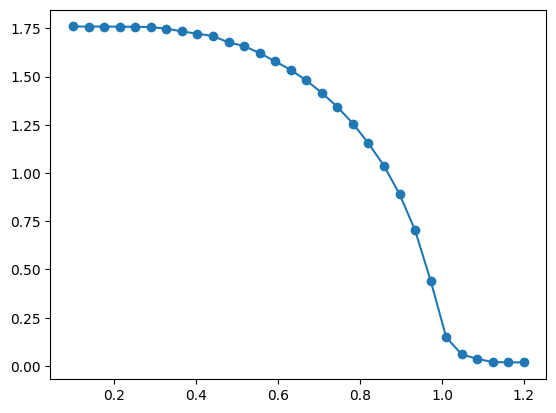

In [14]:
plt.plot(temps,np.abs(gaps[:]), marker = 'o')

### Test a single function run

In [6]:
#comp_grid = mesh_generator.get_computation_grid(omega_sampling = nw, theta_sampling = ntheta, cutoff = cutoff, fine_omega_sampling = fine_nw, fine_cutoff = fine_cutoff)
# compute the parameters
#params = parameter_generator.get_system_parameters(temperature = temperature, mesh_dictionary = comp_grid, critical_temperature = 1, self_energy_coefficients = self_energy_coefficients, gap_symmetry = 's', vector_potential_params = None)
    
def temperature_sweep_function(temperature):
    return Eilenberger_run.calc_equlibrium(temperature= temperature,params_dict = params, meshgrid = comp_grid, gr0 = None)

jitted_function = jax.jit(temperature_sweep_function)

gap, gr, sigma_r = jitted_function(temperature = 0.3)

(13200,)
(2200, 6)
(2200, 6, 6)
(6,)


In [7]:
temps = np.linspace(0.1,1.2,10)
gaps = []
gr = None
for temp in tqdm(temps):
    gap, gr, sigma_r = jitted_function(temperature = temp)
    gaps += [gap]
    
plt.plot(temps,gaps[:], marker = 'o')

  0%|          | 0/10 [00:00<?, ?it/s]

(13200,)
(2200, 6)
(2200, 6, 6)
(6,)


  0%|          | 0/10 [00:05<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
print('Max of sigma_r is',np.max(np.abs(sigma_r)))

### Compute equilibrium for multiple functions

In [ ]:
ts = np.linspace(0.01,1.2,10)
gaps = []
gr = None
sigma_rs = []
for temp in tqdm(ts):
    self_energy_coefficients = {'Elastic':0.5}
    params = parameter_generator.get_system_parameters(temperature = temp, mesh_dictionary = comp_grid, critical_temperature = 1, self_energy_coefficients = self_energy_coefficients, gap_symmetry = 's', vector_potential_params = None)
    gap, gr, sigma_r = Eilenberger_run.calc_equlibrium(params_dict = params, meshgrid = comp_grid,gr0 = gr)
    gaps += [np.abs(gap)]
    sigma_rs +=[sigma_r]

In [ ]:
plt.plot(ts,gaps[:], marker = 'o')
plt.axhline(0.,color='gray',linestyle='dashed')
plt.axhline(nambu_support.get_bcs_ratio(), color='gray',linestyle='dashed')
plt.show()